# Notebook 01 — SimpleMLP 784→8→4→2 on MNIST even/odd (digits 0, 1, 3, 4)

**Architecture:** SimpleMLP with hidden dims [8, 4], trained on MNIST digits 0, 1, 3, 4 with even/odd binary labels.

## Structure
0. **Imports & setup**
1. **Configuration**
2. **Backward Factor Trace** — seed-0 model, BFT, exploratory plots (pixel receptive fields, scaffold graphs)
3. **BFT figures** — main-paper figure 2 and its appendix companion
4. **Fingerprints** — NNLS factor tree, fingerprint similarity, near-OOD (excluded digits), far-OOD (synthetic)
5. **Fingerprint figures** — main paper and appendix (placeholders)

Validation, robustness and ablation analyses live in notebook 09.

## §0 — Imports & setup

In [ ]:
#%matplotlib inline
import sys, os
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor

from src import (
    SimpleMLP, load_experiment, get_transform, get_loaders_from_config,
    collect_layer_inputs_generic, collect_layer_dicts, bft, evaluate, build_scaffold_edges,
    scaffold_loading_from_edges, plot_scaffold_graph, extract_tree_nodes,
    extract_factor_tree_nodes, extract_fingerprint_matrix, compute_stimulus_similarity,
    project_stimuli_onto_tree, compute_factor_activations, plot_factor_tree,
    plot_input_layer_factors, plot_embedding_comparison, save_experiment,
)
from src.training import train_epoch, label_transform_even_odd
from src.data_utils import get_mnist_loaders, label_transformed_loader

matplotlib.rcParams.update({'figure.dpi': 80})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

## §1 — Configuration

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
_nb_dir   = os.path.dirname(os.path.abspath('__file__'))
_repo_dir = os.path.dirname(_nb_dir)

MODEL_ROOT = os.path.join(_repo_dir, 'data', 'models')
FIG_DIR    = os.path.join(_repo_dir, 'figs', '01_mlp_8_4_0134')
for d in [MODEL_ROOT, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Experiment ────────────────────────────────────────────────────────────────
EXP_BASE     = 'mnist_even_odd_mlp_8_4_0134'
N_EPOCHS     = 30
DIGIT_FILTER = [0, 1, 3, 4]
N_CLASSES    = 2
CLASS_NAMES  = {0: 'even', 1: 'odd'}
IMAGE_SIDE   = 28

BASE_CONFIG = {
    'arch': 'SimpleMLP',
    'arch_kwargs': {'input_dim': 784, 'hidden_dims': [8, 4], 'output_dim': 2},
    'dataset': 'MNIST',
    'dataset_kwargs': {'root': '../data/', 'batch_size': 32,
                       'digit_filter': DIGIT_FILTER},
    'label_transform': 'even_odd',
    'analysis_layer_indices': [2, 4, 6],
    'n_per_class': 1000,
    'input_side': 28,
}

# ── BFT config — PUBLICATION SETTINGS (see PUBLICATION_SETTINGS.md) ───────────
# From the nb09 S10 sweep (`rank x0.7`, run 4). The sweep passed [4, 1, 1], but bft's
# _auto_k_factorize floors k_max at 2 (`max(int(k_max), 2)`), so 1 and 2 behave identically
# here -- verified bit-identical fingerprints. [4, 2, 2] is written instead because it is
# what actually executes.
#
# Net effect vs the old [5, 5, 5]: ONLY the input layer changes (rank 5 -> 4). The root and
# hidden layers already auto-selected K = 2 / 1 / 2 and are untouched. Measured:
#   silhouette  0.666 -> 0.711     fingerprint  15 -> 13 dims
#   median causal R2  0.968 -> 0.955   BUT worst-node R2  0.778 -> 0.838 (improves)
N_BRANCHES         = [1, 1, 2]
K_MAX_PER_LAYER    = [4, 2, 2]
STIMULUS_THRESHOLD = 0.5
# Causal-validation sample count. The default (100) is what produced the spurious
# R2 = -0.484 input node; at 2000 the same node reconstructs at +0.778.
VALIDATE_TOP_M     = 2000

# ── Fingerprint / OOD config (§4) ─────────────────────────────────────────────
N_FAR_OOD = 300

print(f'MODEL_ROOT: {MODEL_ROOT}')
print(f'FIG_DIR:    {FIG_DIR}')

## §2 — Backward Factor Trace (seed 0)

### 2a — Model, loaders and layer activations

In [ ]:
# ── Seed-0 model: load or train ───────────────────────────────────────────────
exp_dir = os.path.join(MODEL_ROOT, f'{EXP_BASE}_seed0')

if os.path.exists(os.path.join(exp_dir, 'weights.pt')):
    model, config = load_experiment(exp_dir, DEVICE)
    print(f'Loaded model from {exp_dir}')
else:
    print('No checkpoint found, training from scratch...')
    torch.manual_seed(0)
    np.random.seed(0)
    model  = SimpleMLP(**BASE_CONFIG['arch_kwargs']).to(DEVICE)
    config = dict(BASE_CONFIG, description=f'{EXP_BASE} seed 0')

    _train_loader, _ = get_mnist_loaders(batch_size=32, root='../data/',
                                         digit_filter=DIGIT_FILTER)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    for ep in range(N_EPOCHS):
        train_epoch(model, _train_loader, optimizer, criterion, DEVICE,
                    label_transform_even_odd)
    save_experiment(model, config, exp_dir)
    print(f'Saved to {exp_dir}')

train_loader, test_loader = get_loaders_from_config(config)
label_transform = get_transform(config['label_transform'])
digit_filter    = config['dataset_kwargs']['digit_filter']
_, test_acc     = evaluate(model, test_loader, nn.CrossEntropyLoss(), DEVICE, label_transform)

linear_indices = model.linear_layer_indices()
LAYER_SIZES    = [model.layers[li].out_features for li in linear_indices]
print(f'Seed-0 test accuracy: {test_acc:.4f}')
print(f'Architecture (per-layer neurons): {LAYER_SIZES}')

In [4]:
from src.data_utils import label_transformed_loader

# Loader yielding even/odd labels, for BFT primary mode (enables validate=True).
val_loader = label_transformed_loader(test_loader, label_transform)

# Collect the SAME samples BFT primary mode uses (loader order, only_correct), so
# downstream per-sample arrays stay aligned with tree_root's img_factors.
_collected  = collect_layer_dicts(model, test_loader, label_transform=label_transform,
                                  device=DEVICE)
all_images   = _collected['images']                              # (N, 1, 28, 28)
all_targets  = _collected['targets']                             # (N,) even/odd labels
all_digits   = _collected['digits']                              # (N,) original digit
layer_inputs = [d['input_fmap'] for d in _collected['layer_data']]  # list[(N, n_in)]
n_samples    = len(all_images)
flat_imgs    = all_images.reshape(n_samples, -1)

print(f'Samples: {n_samples}')
print(f'Class distribution: {dict(zip(*np.unique(all_targets, return_counts=True)))}')
for i, li in enumerate(layer_inputs):
    print(f'  L{i+1} inputs: {li.shape}')

Samples: 4080
Class distribution: {np.int64(0): np.int64(1953), np.int64(1): np.int64(2127)}
  L1 inputs: (4080, 784)
  L2 inputs: (4080, 8)
  L3 inputs: (4080, 4)


### 2b — Run BFT

In [5]:

# Primary mode: pass (model, loader) so BFT collects internally and validate=True works.
tree_root = bft(
    model, val_loader,
    k_max=K_MAX_PER_LAYER,
    n_branches=N_BRANCHES,
    stimulus_threshold=STIMULUS_THRESHOLD,
    weighting='img_selectivity',
    validate=True,
    validate_top_m=VALIDATE_TOP_M,
    verbose=1,
    n_jobs=3,
)
print('Validation summary:', tree_root.validation_summary())


def get_nodes_by_depth(root):
    from collections import deque
    by_depth = {}
    queue = deque([(root, 0)])
    while queue:
        node, d = queue.popleft()
        by_depth.setdefault(d, []).append(node)
        for child in node.children:
            queue.append((child, d+1))
    return by_depth

def get_all_paths(root):
    if not root.children: return [[root]]
    return [[root] + p for child in root.children for p in get_all_paths(child)]

nodes_by_depth = get_nodes_by_depth(tree_root.root)
all_paths      = get_all_paths(tree_root.root)
print(f'Tree: {len(nodes_by_depth)} depths, {sum(len(v) for v in nodes_by_depth.values())} nodes, {len(all_paths)} paths')

[BFT] Layer 3/3 'layers.5' (fc)  path=[]
[BFT L3 'layers.5' (fc)]   K=2  t=0.030s
[BFT L3 'layers.5' (fc)]   recon: preact_R2=0.981  abs_CE_gap=0.0004  ratio_floored=0.075  (raw=1.926, n_eval=4080)
[BFT] Layer 2/3 'layers.3' (fc)  path=[0]
[BFT L2 'layers.3' (fc)]   K=1  t=0.015s
[BFT L2 'layers.3' (fc)]   recon: preact_R2=0.981  abs_CE_gap=0.0000  ratio_floored=0.007  (raw=2.822, n_eval=100)
[BFT] Layer 1/3 'layers.1' (fc)  path=[0, 0]


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L1 'layers.1' (fc)]   K=5  t=27.486s
[BFT L1 'layers.1' (fc)]   recon: preact_R2=0.947  abs_CE_gap=-0.0000  ratio_floored=0.002  (raw=0.895, n_eval=100)
[BFT] Layer 2/3 'layers.3' (fc)  path=[1]
[BFT L2 'layers.3' (fc)]   K=2  t=0.017s
[BFT L2 'layers.3' (fc)]   recon: preact_R2=0.994  abs_CE_gap=0.0000  ratio_floored=0.004  (raw=1.018, n_eval=100)
[BFT] Layer 1/3 'layers.1' (fc)  path=[1, 0]


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L1 'layers.1' (fc)]   K=5  t=28.001s
[BFT L1 'layers.1' (fc)]   recon: preact_R2=-0.484  abs_CE_gap=6.1841  ratio_floored=618.522  (raw=5287.938, n_eval=100)
Validation summary: {'overall': {'loss_ratio_floored': {'n': 5, 'mean': 123.72193029012222, 'median': 0.006676703691482544, 'min': 0.002273823833093047, 'max': 618.5220947265625, 'std': 247.40008372558657}, 'abs_ce_gap': {'n': 5, 'mean': 1.2368903010103158, 'median': 4.311078460887074e-05, 'min': -2.6596989482641202e-06, 'max': 6.184051262512804, 'std': 2.473580484421254}, 'preact_r2': {'n': 5, 'mean': 0.6836696697122464, 'median': 0.9806072163623307, 'min': -0.4840818111039702, 'max': 0.9938837288068572, 'std': 0.5840805749434835}, 'loss_ratio_all': {'n': 5, 'mean': 1058.9198920791546, 'median': 1.925711615108519, 'min': 0.8952789386387341, 'max': 5287.938423018231, 'std': 2114.5093798707976}}, 'per_layer': {0: {'loss_ratio_floored': {'n': 2, 'mean': 309.2621842751978, 'median': 309.2621842751978, 'min': 0.002273823833093047

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


### 2c — Exploratory plots: input-layer pixel receptive fields

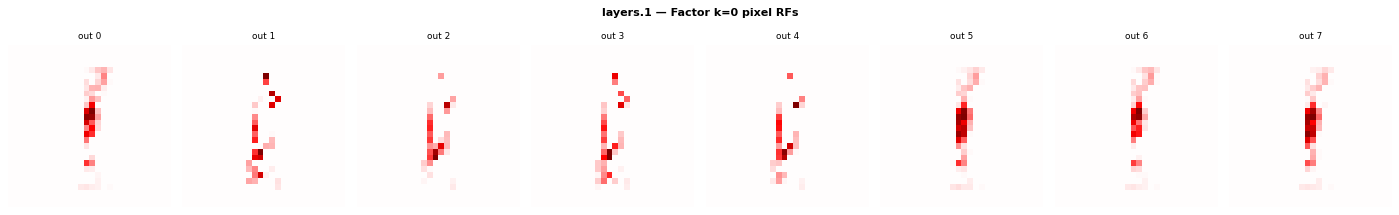

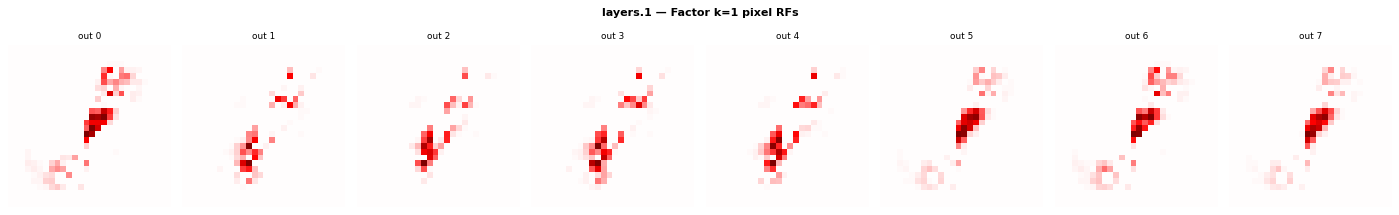

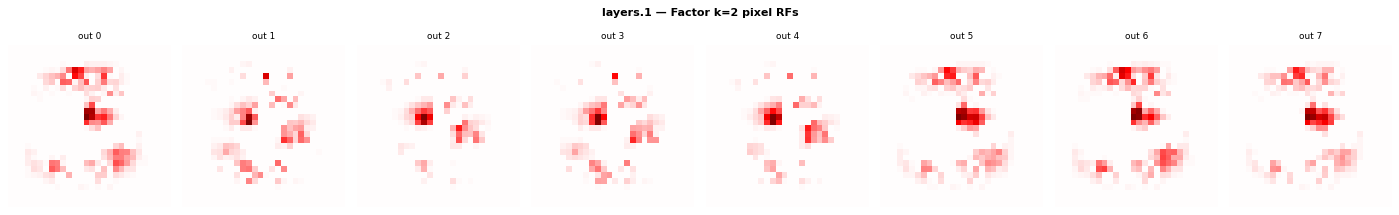

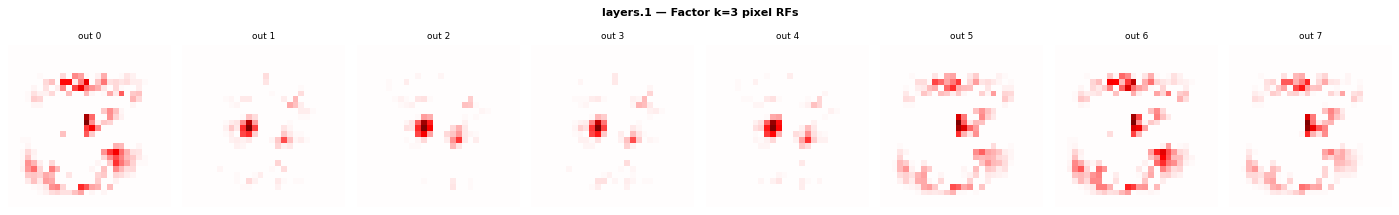

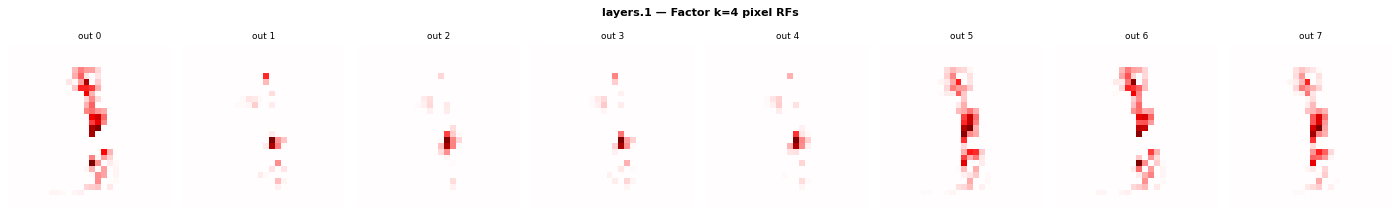

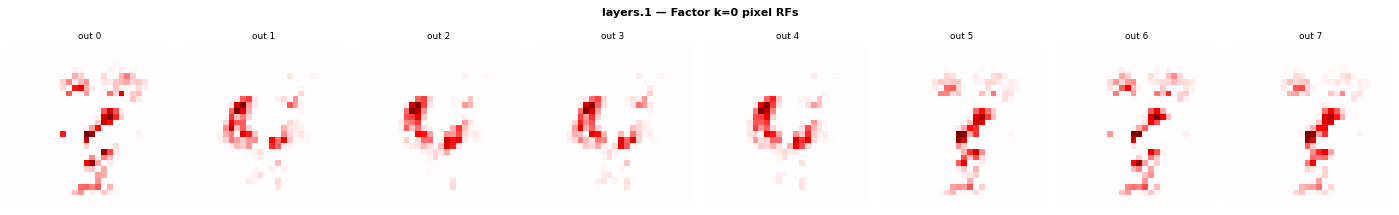

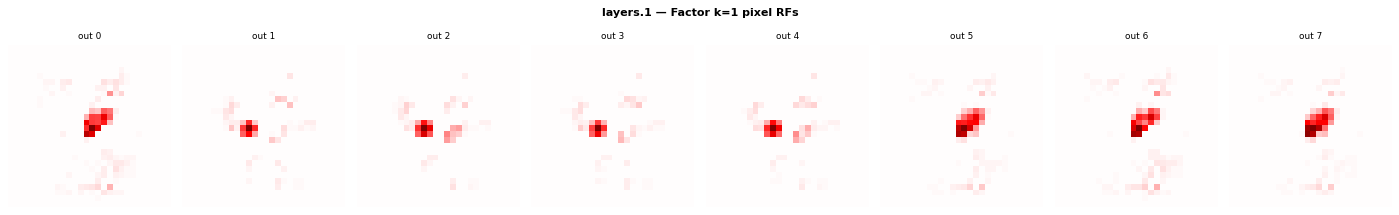

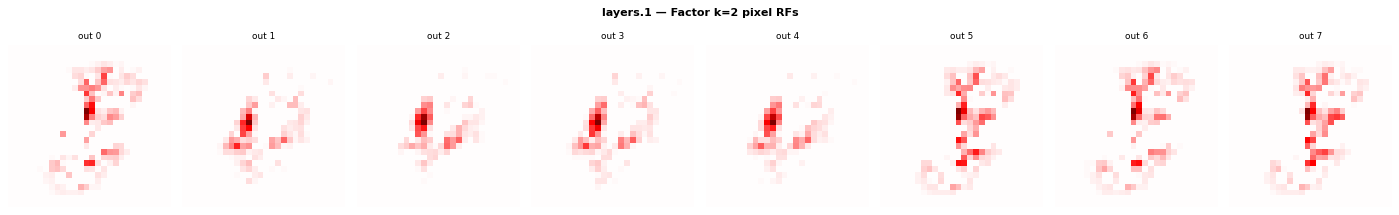

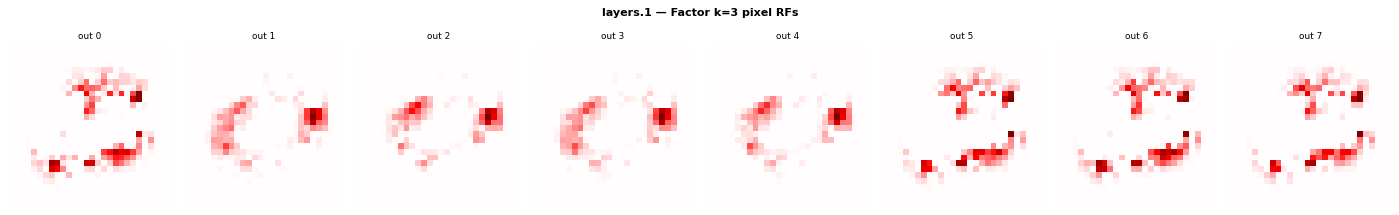

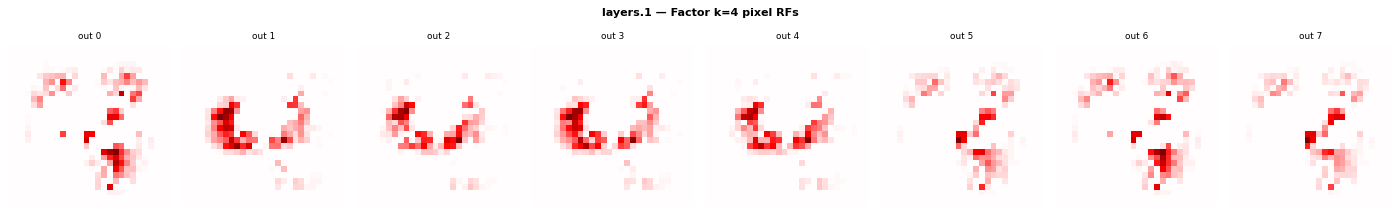

In [7]:
# ── Plot 2: Input-layer pixel receptive fields ────────────────────────────────
# Shows connection_factors[:, k] for each L1 node reshaped to (n_out, 28, 28)
max_depth = max(nodes_by_depth.keys())
for r in nodes_by_depth[max_depth]:
    path_label = 'F' + '→F'.join(str(f) for f in r.path) if r.path else 'root'
    figs = plot_input_layer_factors(
        r, all_images, arch='fc', image_shape=(IMAGE_SIDE, IMAGE_SIDE)
    )
    for k, fig in enumerate(figs):
        fname = f"pixel_rf_L{r.layer_idx+1}_{path_label.replace('→','-')}_k{k}.pdf"
        fig.savefig(os.path.join(FIG_DIR, fname), bbox_inches='tight')
        plt.show(); plt.close(fig)


### 2d — Exploratory plots: full-network scaffold graphs

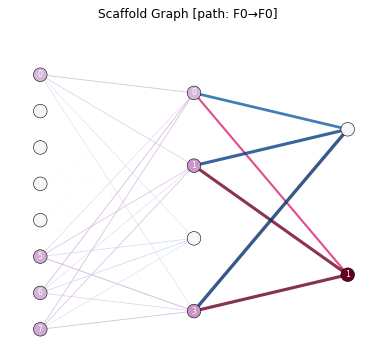

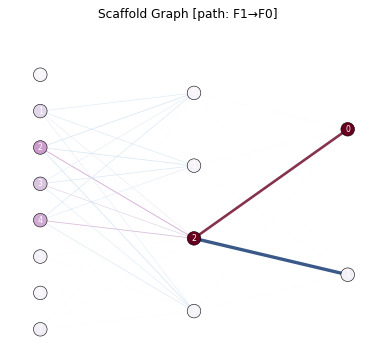

In [8]:
for path_nodes in all_paths:
    layer_results = list(reversed(path_nodes))  # L1-first order

    edge_matrices, neg_edge_matrices = build_scaffold_edges(
        layer_results[1:], fi='path', fi_seed=layer_results[0], top_pct=0.05,
    )
    loading = scaffold_loading_from_edges(edge_matrices)

    path_label = 'F' + '→F'.join(str(f) for f in path_nodes[-1].path)

    fig = plot_scaffold_graph(loading, edge_matrices, LAYER_SIZES,
                              neg_edge_matrices=neg_edge_matrices)
    fig.suptitle(f'Scaffold Graph [path: {path_label}]', fontsize=11)

    _pl = path_label.replace('→', '-')
    fig.savefig(os.path.join(FIG_DIR, f'scaffold_{_pl}.pdf'), bbox_inches='tight')
    plt.show()


## §3 — BFT figures (main paper & appendix)

### 3a — Main-paper figure 2 — class and sub-class circuits

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# PAPER FIGURE 2 (main text, full width) — class and sub-class circuits in the MLP
# Requires: tree_root, all_digits, all_images, LAYER_SIZES  (§2 above)
# Builds:   figures/figdata/nb01_circuits.npz  — also feeds the appendix figure, and
#           is what lets the figure be redrawn on a machine without the models.
# Writes:   figures/fig2_mlp_circuits.pdf  (+ figures/preview/*.png)
# Note: figstyle.apply() sets rcParams globally for the rest of the session.
# ═══════════════════════════════════════════════════════════════════════════════
import figstyle          # repo root; styling + venue geometry for AAAI
from src import figdata
from src.paper_figures import fig2_mlp_circuits

DIGIT_ORDER = [0, 4, 1, 3]          # even digits first, then odd
IMAGE_SIDE  = 28


def digit_loading(node, k, digits=None, digit_order=DIGIT_ORDER):
    """Share of factor k's mean stimulus loading contributed by each digit."""
    digits = all_digits if digits is None else digits
    col = node.img_factors[:, k]
    m = np.array([col[digits == d].mean() for d in digit_order])
    return m / (m.sum() + 1e-12)


def digit_profiles(node):
    return np.stack([digit_loading(node, k) for k in range(node.img_factors.shape[1])])


def pixel_arbors(node, neg=False):
    """(K, 28, 28): pixel-space arbor of every factor of an input-layer node."""
    F = node.neg_connection_factors if neg else node.connection_factors
    n_out, n_in = node.weight.shape
    return np.stack([F[:, k].reshape(n_out, n_in).sum(0).reshape(IMAGE_SIDE, IMAGE_SIDE)
                     for k in range(F.shape[1])])


def conn_map(node, k, neg=False):
    """One factor's connection map, shaped (out unit, in unit)."""
    F = node.neg_connection_factors if neg else node.connection_factors
    return F[:, k].reshape(node.weight.shape)


def weighted_avg_stimuli(node, flat_images):
    """(K, 28, 28): the stimulus average each factor's loadings define."""
    W = node.img_factors
    return np.stack([(W[:, k, None] * flat_images).sum(0) / (W[:, k].sum() + 1e-12)
                     for k in range(W.shape[1])]).reshape(-1, IMAGE_SIDE, IMAGE_SIDE)


# ── index the trace tree; identify the even / odd root factor from the data ──
root = tree_root.root
by_path = {}


def _walk(n):
    by_path[tuple(n.path)] = n
    for ch in n.children:
        _walk(ch)


_walk(root)

_even_cols = [i for i, d in enumerate(DIGIT_ORDER) if d % 2 == 0]
root_even_k = int(np.argmax([digit_loading(root, k)[_even_cols].sum()
                             for k in range(root.img_factors.shape[1])]))
_flat = all_images.reshape(len(all_images), -1)

# ── export everything the two figures draw (a superset: all factors, both signs,
#    so panels can be redesigned without re-running the trace) ────────────────
circuits = []
for name, k in (('even', root_even_k), ('odd', 1 - root_even_k)):
    l2, l1 = by_path[(k,)], by_path[(k, 0)]
    chain = list(reversed([root, l2, l1]))                      # L1-first
    E, negE = build_scaffold_edges(chain[1:], fi='path', fi_seed=chain[0], top_pct=0.05)
    cf0 = l1.connection_factors[:, 0].reshape(l1.weight.shape)
    circuits.append(dict(
        name=name, color_key=name, k=k,
        l3_profile=digit_loading(root, k),
        l3_conn=conn_map(root, k), l3_conn_neg=conn_map(root, k, neg=True),
        l2_lam=l2.lambdas / l2.lambdas.sum(), l2_profiles=digit_profiles(l2),
        l2_conn=conn_map(l2, 0), l2_conn_neg=conn_map(l2, 0, neg=True),
        l1_lam=l1.lambdas / l1.lambdas.sum(), l1_profiles=digit_profiles(l1),
        l1_arbors=pixel_arbors(l1), l1_neg_arbors=pixel_arbors(l1, neg=True),
        l1_unit_rf=cf0.reshape(-1, IMAGE_SIDE, IMAGE_SIDE),
        l1_unit_share=cf0.sum(1) / (cf0.sum() + 1e-12),
        l1_wavg=weighted_avg_stimuli(l1, _flat),
        scaffold=dict(edges=E, neg_edges=negE,
                      loading=scaffold_loading_from_edges(E))))

D = figdata.save('nb01_circuits', dict(
    digit_order=DIGIT_ORDER, layer_sizes=LAYER_SIZES, out_labels=['even', 'odd'],
    root_lam=root.lambdas / root.lambdas.sum(),
    root_factor_color_keys=['even' if i == root_even_k else 'odd'
                            for i in range(root.img_factors.shape[1])],
    circuits=circuits))

fig = fig2_mlp_circuits(D)
figstyle.save_fig(fig, 'fig2_mlp_circuits')
plt.show()


### 3b — Appendix figure — decomposition details

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# PAPER APPENDIX FIGURE — decomposition details for the 8x4 MLP
# Requires: the nb01_circuits bundle built by the main-figure cell above
# Writes:   figures/appendix/figA_mlp_details.pdf  (+ preview PNG)
# ═══════════════════════════════════════════════════════════════════════════════
from src.paper_figures import figA_mlp_details

fig = figA_mlp_details(figdata.load('nb01_circuits'))
figstyle.save_fig(fig, 'figA_mlp_details')
plt.show()


## §4 — Fingerprints

In [ ]:
# §3 calls figstyle.apply(), which sets rcParams globally for the rest of the
# session. Reset to the notebook defaults so the exploratory plots below render
# at screen size rather than at venue column width.
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'figure.dpi': 80})

### 4a — NNLS round-trip on the publication factor tree

In [ ]:
# ── Fingerprint basis = the publication tree from §2 ──────────────────────────
# §4 and §5 project new stimuli onto the SAME factors the paper's circuit figure
# shows, so a fingerprint dimension means the same thing as a node in Fig. 2.
# This section used to build a second, wider tree (k_max=[10,1,2],
# n_branches=[8,2,2], stimulus_threshold=0). Measured against it, the publication
# tree is better on every axis: round-trip cosine 0.994 ± 0.040 vs 0.740 ± 0.106,
# even/odd silhouette 0.890 vs 0.617, and 13 dimensions instead of 35.
fp_tree_nodes   = extract_tree_nodes(tree_root)
fp_factor_nodes = extract_factor_tree_nodes(tree_root)

# Round-trip test: NNLS-project the test set back onto the fixed factors and
# compare with the fingerprints the NMF itself produced.
from sklearn.metrics.pairwise import paired_cosine_distances as _pcd
projected_test_rt = project_stimuli_onto_tree(tree_root, layer_inputs)
F_orig  = extract_fingerprint_matrix(tree_root, np.arange(n_samples))
F_rt    = extract_fingerprint_matrix(projected_test_rt, np.arange(n_samples))
rt_sims = 1.0 - _pcd(F_orig, F_rt)
print(f'Round-trip cosine sim: mean={rt_sims.mean():.4f}  std={rt_sims.std():.4f}  min={rt_sims.min():.4f}')


### 4b — Factor fingerprints & similarity (test set)

In [ ]:
F = extract_fingerprint_matrix(tree_root, np.arange(n_samples))
print(f'Fingerprint matrix: {F.shape}')

MAX_VIZ = 300
viz_idx     = np.argsort(all_targets)[:MAX_VIZ] if n_samples > MAX_VIZ else np.argsort(all_targets)
S           = compute_stimulus_similarity(F[viz_idx])
targets_viz = all_targets[viz_idx]

# ── Similarity heatmap + intra/inter histogram ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(S, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0])
for cl in np.unique(targets_viz):
    for b in np.where(np.diff((targets_viz == cl).astype(int)))[0]:
        axes[0].axhline(b + 0.5, color='k', lw=0.5)
        axes[0].axvline(b + 0.5, color='k', lw=0.5)
axes[0].set(title='Factor fingerprint similarity (sorted by class)',
            xlabel='Stimulus', ylabel='Stimulus')

S_all = compute_stimulus_similarity(F)
classes = sorted(np.unique(all_targets))
intra_vals, inter_vals = [], []
for ci, cl in enumerate(classes):
    mask  = all_targets == cl
    intra = S_all[np.ix_(mask, mask)]
    intra_vals.extend(intra[np.triu_indices_from(intra, k=1)])
    for cl2 in classes[ci + 1:]:
        inter_vals.extend(S_all[np.ix_(mask, all_targets == cl2)].ravel())
intra_arr, inter_arr = np.array(intra_vals), np.array(inter_vals)
axes[1].hist(intra_arr, bins=60, alpha=0.6, density=True,
             label=f'Intra ({intra_arr.mean():.3f})')
axes[1].hist(inter_arr, bins=60, alpha=0.6, density=True,
             label=f'Inter ({inter_arr.mean():.3f})')
axes[1].set(xlabel='Cosine similarity', ylabel='Density',
            title='Intra- vs inter-class fingerprint similarity')
axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'nnls_fingerprints.pdf'), bbox_inches='tight')
plt.show()

# ── Plot 7: Embedding comparison ───────────────────────────────────────────────
# Panels: PCA(fingerprints) | PCA(last-layer) | PCA(all-layers) | MDS(fingerprints)
full_acts_id = np.concatenate([li[viz_idx] for li in layer_inputs], axis=1)
fig = plot_embedding_comparison(
    F[viz_idx], layer_inputs[-1][viz_idx], targets_viz,
    CLASS_NAMES, digit_targets=all_digits[viz_idx],
    activations_all=full_acts_id,
    title='ID test-set fingerprint embeddings',
)
fig.savefig(os.path.join(FIG_DIR, 'embedding_comparison_id.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)

### 4c — Near-OOD: excluded MNIST digits (2, 5, 6, 7, 8, 9)

In [ ]:
OOD_DIGITS = [d for d in range(10) if d not in digit_filter]
print(f'OOD digits: {OOD_DIGITS}')

mnist_test_full = datasets.MNIST('../data/', train=False, download=True, transform=ToTensor())
ood_labels_all  = np.array(mnist_test_full.targets)
ood_indices     = np.where(np.isin(ood_labels_all, OOD_DIGITS))[0]
ood_subset      = Subset(mnist_test_full, ood_indices)

data_ood = collect_layer_inputs_generic(
    model, ood_subset, label_transform=label_transform_even_odd,
    only_correct=False, device=DEVICE,
)
ood_images  = data_ood['images']
ood_digits  = data_ood['digits']
ood_targets = data_ood['targets']
ood_inputs  = data_ood['layer_inputs']
n_ood       = len(ood_images)
print(f'OOD samples: {n_ood}')

ood_preds        = data_ood['preds']   # what the network says, for §5
projected_ood    = project_stimuli_onto_tree(tree_root, ood_inputs)
factor_nodes_ood = extract_factor_tree_nodes(projected_ood)

# ── Factor tree per OOD digit ─────────────────────────────────────────────────
unique_ood = sorted(np.unique(ood_digits))
ncols = min(3, len(unique_ood))
nrows = int(np.ceil(len(unique_ood) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
for i, d in enumerate(unique_ood):
    ax   = axes[i // ncols][i % ncols]
    idx  = np.where(ood_digits == d)[0]
    acts = compute_factor_activations(factor_nodes_ood, idx)
    parity = 'even' if d % 2 == 0 else 'odd'
    plot_factor_tree(factor_nodes_ood, acts, ax=ax,
                     title=f'OOD digit {d} ({parity})  n={len(idx)}')
for j in range(len(unique_ood), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)
plt.suptitle('Near-OOD — Factor tree per excluded digit', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'near_ood_tree_per_digit.pdf'), bbox_inches='tight')
plt.show()

# ── Plot 7: Embedding comparison — ID test vs near-OOD ────────────────────────
N_EACH = 150
rng_m  = np.random.default_rng(7)
id_sub  = rng_m.choice(n_samples, min(N_EACH, n_samples), replace=False)
ood_sub = rng_m.choice(n_ood, min(N_EACH, n_ood), replace=False)

F_id_sub  = extract_fingerprint_matrix(tree_root, id_sub)
F_ood_sub = extract_fingerprint_matrix(projected_ood, ood_sub)
F_combo   = np.concatenate([F_id_sub, F_ood_sub])
act_combo = np.concatenate([layer_inputs[-1][id_sub], ood_inputs[-1][ood_sub]])
lbl_combo = np.concatenate([all_targets[id_sub], ood_targets[ood_sub]])
digit_combo = np.concatenate([all_digits[id_sub], ood_digits[ood_sub]])
cond_combo  = (['ID'] * len(id_sub)) + (['near-OOD'] * len(ood_sub))

full_id_sub  = np.concatenate([li[id_sub]  for li in layer_inputs], axis=1)
full_ood_sub = np.concatenate([li[ood_sub] for li in ood_inputs],   axis=1)
full_combo   = np.concatenate([full_id_sub, full_ood_sub],           axis=0)

fig = plot_embedding_comparison(
    F_combo, act_combo, lbl_combo,
    CLASS_NAMES, digit_targets=digit_combo,
    condition_labels=cond_combo,
    activations_all=full_combo,
    title='Near-OOD vs ID fingerprint embeddings',
)
fig.savefig(os.path.join(FIG_DIR, 'embedding_comparison_near_ood.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)

### 4d — Far-OOD: synthetic images

In [ ]:
rng_f = np.random.default_rng(99)
_chk  = (np.indices((IMAGE_SIDE, IMAGE_SIDE)).sum(0) % 2).astype(np.float32)

far_ood_arrays = {
    'gaussian_noise': np.clip(
        rng_f.normal(0.5, 0.25, (N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE)).astype(np.float32), 0, 1),
    'uniform_gray':   np.full((N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE), 0.5, dtype=np.float32),
    'checkerboard':   np.broadcast_to(_chk, (N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE)).copy().astype(np.float32),
    'inverted_test':  np.clip(1.0 - all_images[:N_FAR_OOD], 0, 1).astype(np.float32),
}

far_ood_data = {}
for name, imgs in far_ood_arrays.items():
    ds = TensorDataset(torch.from_numpy(imgs),
                       torch.zeros(len(imgs), dtype=torch.long))
    d = collect_layer_inputs_generic(
        model, ds, label_transform=label_transform_even_odd,
        only_correct=False, device=DEVICE,
    )
    d['projected_root'] = project_stimuli_onto_tree(tree_root, d['layer_inputs'])
    d['factor_nodes']   = extract_factor_tree_nodes(d['projected_root'])
    far_ood_data[name]  = d
    print(f'{name:20s}  model acc={(d["preds"] == d["targets"]).mean():.3f}')

# ── Factor tree per far-OOD type ──────────────────────────────────────────────
n_types = len(far_ood_data)
fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 4.5), squeeze=False)
axes = axes[0]
for ax, (name, d) in zip(axes, far_ood_data.items()):
    acts = compute_factor_activations(d['factor_nodes'], np.arange(len(d['images'])))
    plot_factor_tree(d['factor_nodes'], acts, ax=ax, title=name)
plt.suptitle('Far OOD — factor tree activation per synthetic type', y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_factor_tree.pdf'), bbox_inches='tight')
plt.show()

# ── Plot 7: Embedding comparison — ID / near-OOD / far-OOD ───────────────────
N_MDS = 80
rng_m2 = np.random.default_rng(5)

F_parts, act_parts, full_parts, lbl_parts, digit_parts, cond_parts = [], [], [], [], [], []

# ID test
id_s2 = rng_m2.choice(n_samples, min(N_MDS, n_samples), replace=False)
F_parts.append(extract_fingerprint_matrix(tree_root, id_s2))
act_parts.append(layer_inputs[-1][id_s2])
full_parts.append(np.concatenate([li[id_s2] for li in layer_inputs], axis=1))
lbl_parts.append(all_targets[id_s2])
digit_parts.append(all_digits[id_s2])
cond_parts.extend(['ID-test'] * len(id_s2))

# Near-OOD
ood_s2 = rng_m2.choice(n_ood, min(N_MDS, n_ood), replace=False)
F_parts.append(extract_fingerprint_matrix(projected_ood, ood_s2))
act_parts.append(ood_inputs[-1][ood_s2])
full_parts.append(np.concatenate([li[ood_s2] for li in ood_inputs], axis=1))
lbl_parts.append(ood_targets[ood_s2])
digit_parts.append(ood_digits[ood_s2])
cond_parts.extend(['near-OOD'] * len(ood_s2))

# Far-OOD types
for name, d in far_ood_data.items():
    n  = min(N_MDS, len(d['images']))
    ss = rng_m2.choice(len(d['images']), n, replace=False)
    F_parts.append(extract_fingerprint_matrix(d['projected_root'], ss))
    act_parts.append(d['layer_inputs'][-1][ss])
    full_parts.append(np.concatenate([li[ss] for li in d['layer_inputs']], axis=1))
    lbl_parts.append(d['targets'][ss])
    digit_parts.append(np.full(n, -1))
    cond_parts.extend([name] * n)

F_joint     = np.concatenate(F_parts)
act_joint   = np.concatenate(act_parts)
lbl_joint   = np.concatenate(lbl_parts)
digit_joint = np.concatenate(digit_parts)

fig = plot_embedding_comparison(
    F_joint, act_joint, lbl_joint,
    CLASS_NAMES, digit_targets=None,
    condition_labels=cond_parts,
    far_ood_conditions=list(far_ood_data.keys()),
    activations_all=np.concatenate(full_parts, axis=0),
    title='ID / near-OOD / far-OOD fingerprint embeddings',
)
fig.savefig(os.path.join(FIG_DIR, 'embedding_comparison_all_ood.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)

## §5 — Fingerprint figures (main paper & appendix)

### 5a — Main-paper figure

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PAPER FIGURE 4 (main text, full width) — factor fingerprints in the 8x4 MLP
# Requires: tree_root, F, all_targets, all_digits, layer_inputs  (§2, §4b)
#           projected_ood, ood_digits, ood_preds, n_ood  (§4c)
#           far_ood_data  (§4d) and rt_sims (§4a)
# Builds:   figures/figdata/nb01_fingerprints.npz — also feeds the appendix figure
# Writes:   figures/fig4_mlp_fingerprints.pdf  (+ figures/preview/*.png)
# Note: figstyle.apply() sets rcParams globally for the rest of the session.
# ═══════════════════════════════════════════════════════════════════════════════
import figstyle          # repo root; styling + venue geometry for AAAI
from src import figdata
from src.paper_figures import fig4_mlp_fingerprints, unit
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

DIGIT_ORDER = [0, 4, 1, 3]                       # even digits first, then odd
FAR_LABEL   = {'gaussian_noise': 'noise', 'uniform_gray': 'gray',
               'checkerboard': 'checker', 'inverted_test': 'inverted'}

# ── fingerprints of the OOD conditions, on the §2 factors ───────────────────
F_ood = extract_fingerprint_matrix(projected_ood, np.arange(n_ood))
F_far = {name: extract_fingerprint_matrix(d['projected_root'],
                                          np.arange(len(d['images'])))
         for name, d in far_ood_data.items()}

# ── map every fingerprint dim to its (layer, root branch, factor) ───────────
# extract_fingerprint_matrix concatenates nodes in BFS order, so this reproduces
# the column order of F.
_dims, _q = [], [tree_root.root]
while _q:
    _n = _q.pop(0)
    for _k in range(_n.img_factors.shape[1]):
        _dims.append((_n.layer_idx, _n.path[0] if _n.path else -1, _k))
    _q.extend(_n.children)
_dims  = np.array(_dims)
_top   = _dims[:, 0].max()
ROOT_K = np.where(_dims[:, 0] == _top)[0]

# which root factor is the even one (read off the data, as in Fig. 2)
_is_even = all_targets == 0
K_EVEN = int(ROOT_K[np.argmax([F[_is_even, k].mean() - F[~_is_even, k].mean()
                               for k in ROOT_K])])
K_ODD  = int([k for k in ROOT_K if k != K_EVEN][0])


def _circuit_cols(k_root):
    """The fingerprint dims belonging to one root factor's circuit."""
    return [int(k_root)] + [i for i in range(len(_dims))
                            if _dims[i, 0] != _top and _dims[i, 1] == _dims[k_root, 2]]


COLS_EVEN, COLS_ODD = _circuit_cols(K_EVEN), _circuit_cols(K_ODD)
COL_ORDER = COLS_EVEN + COLS_ODD
N_EV = len(COLS_EVEN)


# ── (c) what the fingerprint says vs what the network says ─────────────────
def odd_share(Fm):
    """Share of the two root factors' mass carried by the odd circuit."""
    o, e = Fm[:, K_ODD], Fm[:, K_EVEN]
    return o / (o + e + 1e-12)


ood_pts = [(d, (ood_preds[ood_digits == d] == 1).mean(),
            odd_share(F_ood[ood_digits == d]).mean())
           for d in sorted(np.unique(ood_digits))]
id_pts  = [(d, (all_targets[all_digits == d] == 1).mean(),
            odd_share(F[all_digits == d]).mean()) for d in DIGIT_ORDER]
R_OOD = np.corrcoef([p[1] for p in ood_pts], [p[2] for p in ood_pts])[0, 1]


# ── (d) how tightly each condition's fingerprints cluster ──────────────────
def centroid_cos(Fm):
    """Cosine of every fingerprint to its own condition's mean fingerprint."""
    U = unit(Fm)
    c = U.mean(0)
    return U @ (c / (np.linalg.norm(c) + 1e-12))


COND = ([dict(label='ID test', values=centroid_cos(F), color_key='id_data'),
         dict(label='held-out digits', values=centroid_cos(F_ood),
              color_key='near_ood')] +
        [dict(label=FAR_LABEL[n], values=centroid_cos(F_far[n]), color_key='far_ood')
         for n in far_ood_data])

SIL_CLASS = silhouette_score(unit(F), all_targets, metric='cosine')
SIL_DIGIT = silhouette_score(unit(F), all_digits, metric='cosine')
print(f'fingerprint dim: {F.shape[1]}   silhouette: {SIL_CLASS:.3f} (even/odd), '
      f'{SIL_DIGIT:.3f} (digit)')
print(f'held-out digits: r(odd-circuit share, P(model=odd)) = {R_OOD:.4f}')
for c in COND:
    print(f"  {c['label']:16s} cos to condition mean: median {np.median(c['values']):.3f}")

# ── (b) the stimulus sample the similarity matrix is drawn from ────────────
PER = 100
rng_v = np.random.default_rng(1)
sel = np.concatenate([rng_v.choice(np.where(all_digits == d)[0], PER, replace=False)
                      for d in DIGIT_ORDER])

# ── appendix figure: condition means, digit-likeness, separability, PCA ────
ROWS = ([dict(label=str(d), mean=F[all_digits == d].mean(0), color_key=f'digit:{d}')
         for d in DIGIT_ORDER] +
        [dict(label=str(d), mean=F_ood[ood_digits == d].mean(0), color_key='near_ood')
         for d in sorted(np.unique(ood_digits))] +
        [dict(label=FAR_LABEL[n], mean=F_far[n].mean(0), color_key='far_ood')
         for n in far_ood_data])
_n_ood_d = len(np.unique(ood_digits))
GROUP = [dict(label='trained', start=0, stop=4),
         dict(label='held-out', start=4, stop=4 + _n_ood_d),
         dict(label='far-OOD', start=4 + _n_ood_d, stop=len(ROWS))]

# how digit-like each condition's fingerprints are
CENT = unit(np.stack([F[all_digits == d].mean(0) for d in DIGIT_ORDER]))
LIKE = [dict(label=lab, values=(unit(X) @ CENT.T).max(1), color_key=ck) for lab, X, ck in
        ([('ID test', F, 'id_data'), ('held-out digits', F_ood, 'near_ood')] +
         [(FAR_LABEL[n], F_far[n], 'far_ood') for n in far_ood_data])]

# digit separability: the fingerprint against activation controls. The network
# was never trained to tell 0 from 4 or 1 from 3 — its own output-side
# activations barely do, the fingerprint does.
REPS = [('BFT\nfingerprint', unit(F), F.shape[1], 'ours'),
        (r'$L_2$ act.',  layer_inputs[1], layer_inputs[1].shape[1], '0.55'),
        (r'$L_3$ act.',  layer_inputs[2], layer_inputs[2].shape[1], '0.55'),
        ('all act.',     np.concatenate(layer_inputs, axis=1),
         sum(li.shape[1] for li in layer_inputs), '0.55'),
        ('pixels',       layer_inputs[0], layer_inputs[0].shape[1], '0.55')]
SEP = [dict(label=lab, silhouette=silhouette_score(X, all_digits, metric='cosine'),
            knn=cross_val_score(KNeighborsClassifier(5, metric='cosine'), X,
                                all_digits, cv=5).mean(), dim=d, color_key=ck)
       for lab, X, d, ck in REPS]

# fingerprints in the plane of their first two principal components
_pca  = PCA(n_components=2).fit(unit(F))
rng_e = np.random.default_rng(3)


def _emb(X, n):
    idx = rng_e.choice(len(X), min(n, len(X)), replace=False)
    return _pca.transform(unit(X[idx]))


PCA_COORDS = dict(evr=_pca.explained_variance_ratio_[:2],
                  far=[dict(label=n, coords=_emb(F_far[n], 120)) for n in far_ood_data],
                  ood_coords=_emb(F_ood, 500),
                  digits=[dict(digit=d, coords=_emb(F[all_digits == d], 250))
                          for d in DIGIT_ORDER])

D = figdata.save('nb01_fingerprints', dict(
    digit_order=DIGIT_ORDER, dims=_dims, col_order=COL_ORDER, n_ev=N_EV,
    cols_even=COLS_EVEN, cols_odd=COLS_ODD,
    fp_mean_by_digit=np.stack([F[all_digits == d].mean(0) for d in DIGIT_ORDER]),
    fp_sel=F[sel], sel_per_digit=PER,
    sil_class=SIL_CLASS, sil_digit=SIL_DIGIT, r_ood=R_OOD,
    id_pts=np.array(id_pts), ood_pts=np.array(ood_pts), cond=COND,
    rows=ROWS, group=GROUP, like=LIKE, sep=SEP, rt_sims=rt_sims, pca=PCA_COORDS))

fig = fig4_mlp_fingerprints(D)
figstyle.save_fig(fig, 'fig4_mlp_fingerprints')
plt.show()


### 5b — Appendix figure

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PAPER APPENDIX FIGURE — fingerprint details for the 8x4 MLP
# Requires: the nb01_fingerprints bundle built by the main-figure cell above
# Writes:   figures/appendix/figC_mlp_fingerprint_details.pdf  (+ preview PNG)
# ═══════════════════════════════════════════════════════════════════════════════
from src.paper_figures import figC_mlp_fingerprint_details

D = figdata.load('nb01_fingerprints')
for s in D['sep']:                       # the separability table behind panel (d)
    print(f"{s['label'].replace(chr(10), ' '):18s} ({s['dim']:4d}d)  "
          f"silhouette {s['silhouette']:.3f}  5-NN {s['knn']:.3f}")

fig = figC_mlp_fingerprint_details(D)
figstyle.save_fig(fig, 'figC_mlp_fingerprint_details')
plt.show()
